In [79]:
import pandas as pd
import matplotlib.pyplot as plt

In [65]:
df1 = pd.read_csv('data/NEW-DATA-1.T15.txt', delim_whitespace=True, header=0)
df2 = pd.read_csv('data/NEW-DATA-2.T15.txt', delim_whitespace=True, header=0)
print(df1)
print(df2)

          1:Date 2:Time  3:Temperature_Comedor_Sensor  \
0     13/03/2012  11:45                       18.1875   
1     13/03/2012  12:00                       18.4633   
2     13/03/2012  12:15                       18.7673   
3     13/03/2012  12:30                       19.0727   
4     13/03/2012  12:45                       19.3721   
...          ...    ...                           ...   
2759  11/04/2012  05:30                       21.1520   
2760  11/04/2012  05:45                       21.0413   
2761  11/04/2012  06:00                       20.9347   
2762  11/04/2012  06:15                       20.8560   
2763  11/04/2012  06:30                       20.7627   

      4:Temperature_Habitacion_Sensor  5:Weather_Temperature  \
0                             17.8275                 0.0000   
1                             18.1207                 6.8000   
2                             18.4367                17.0000   
3                             18.7513                18.000

In [66]:
fdf = pd.concat([df1, df2], ignore_index=True)
print(fdf)

          1:Date 2:Time  3:Temperature_Comedor_Sensor  \
0     13/03/2012  11:45                       18.1875   
1     13/03/2012  12:00                       18.4633   
2     13/03/2012  12:15                       18.7673   
3     13/03/2012  12:30                       19.0727   
4     13/03/2012  12:45                       19.3721   
...          ...    ...                           ...   
4132  02/05/2012  06:30                       18.8000   
4133  02/05/2012  06:45                       18.7713   
4134  02/05/2012  07:00                       18.7860   
4135  02/05/2012  07:15                       18.8133   
4136  02/05/2012  07:30                       18.8600   

      4:Temperature_Habitacion_Sensor  5:Weather_Temperature  \
0                             17.8275                 0.0000   
1                             18.1207                 6.8000   
2                             18.4367                17.0000   
3                             18.7513                18.000

In [67]:
print(fdf.describe())

       3:Temperature_Comedor_Sensor  4:Temperature_Habitacion_Sensor  \
count                   4137.000000                       4137.00000   
mean                      20.493530                         20.14605   
std                        3.312096                          3.31100   
min                       11.352000                         11.07600   
25%                       18.424600                         18.06930   
50%                       20.499300                         20.14070   
75%                       22.865300                         22.46130   
max                       28.924000                         28.54800   

       5:Weather_Temperature  6:CO2_Comedor_Sensor  7:CO2_Habitacion_Sensor  \
count            4137.000000           4137.000000              4137.000000   
mean               15.092676            206.599835               209.611623   
std                 4.375374             22.763114                24.183477   
min                 0.000000       

In [75]:
print(fdf.dtypes)

1:Date                              object
2:Time                              object
3:Temperature_Comedor_Sensor       float64
4:Temperature_Habitacion_Sensor    float64
5:Weather_Temperature              float64
6:CO2_Comedor_Sensor               float64
7:CO2_Habitacion_Sensor            float64
8:Humedad_Comedor_Sensor           float64
9:Humedad_Habitacion_Sensor        float64
10:Lighting_Comedor_Sensor         float64
11:Lighting_Habitacion_Sensor      float64
12:Precipitacion                   float64
13:Meteo_Exterior_Crepusculo       float64
14:Meteo_Exterior_Viento           float64
15:Meteo_Exterior_Sol_Oest         float64
16:Meteo_Exterior_Sol_Est          float64
17:Meteo_Exterior_Sol_Sud          float64
18:Meteo_Exterior_Piranometro      float64
19:Exterior_Entalpic_1               int64
20:Exterior_Entalpic_2               int64
21:Exterior_Entalpic_turbo           int64
22:Temperature_Exterior_Sensor     float64
23:Humedad_Exterior_Sensor         float64
24:Day_Of_W

In [69]:
# The data only covers 40 days and thus may be baised by the specific season the data was measured in which is unknown
# The day of the week was calculated by the date making it redundant
unused_cols = ['1:Date', '24:Day_Of_Week', '4:Temperature_Habitacion_Sensor', '7:CO2_Habitacion_Sensor', '9:Humedad_Habitacion_Sensor', '11:Lighting_Habitacion_Sensor', '19:Exterior_Entalpic_1', '20:Exterior_Entalpic_2', '21:Exterior_Entalpic_turbo']
df = fdf.drop(unused_cols, axis=1)

In [70]:
print(df.columns)
print(len(df.columns))

Index(['2:Time', '3:Temperature_Comedor_Sensor', '5:Weather_Temperature',
       '6:CO2_Comedor_Sensor', '8:Humedad_Comedor_Sensor',
       '10:Lighting_Comedor_Sensor', '12:Precipitacion',
       '13:Meteo_Exterior_Crepusculo', '14:Meteo_Exterior_Viento',
       '15:Meteo_Exterior_Sol_Oest', '16:Meteo_Exterior_Sol_Est',
       '17:Meteo_Exterior_Sol_Sud', '18:Meteo_Exterior_Piranometro',
       '22:Temperature_Exterior_Sensor', '23:Humedad_Exterior_Sensor'],
      dtype='object')
15


In [71]:
df.columns = ['Time', 'Indoor Temp', 'Weather Temp', 'CO2', 'Relative Humidity', 'Lighting', 'Rain', 'Sun', 'Wind', 'Sunlight(West)', 'Sunlight(East)', 'Sunlight(South)', 'Sun Irradiance', 'Outdoor Temp', 'Outdoor Relative Humidity']

In [72]:
#Percent of each column that is empty
print((df.isna().sum() / df.shape[0])*100)
print(df.shape[0])

Time                         0.0
Indoor Temp                  0.0
Weather Temp                 0.0
CO2                          0.0
Relative Humidity            0.0
Lighting                     0.0
Rain                         0.0
Sun                          0.0
Wind                         0.0
Sunlight(West)               0.0
Sunlight(East)               0.0
Sunlight(South)              0.0
Sun Irradiance               0.0
Outdoor Temp                 0.0
Outdoor Relative Humidity    0.0
dtype: float64
4137


In [73]:
def plot(col):
    df[col].plot(kind='box')
    plt.title(col)
    plt.grid()
    plt.show()

In [82]:
def time_clean(val):
    string = str(val)
    string = string.replace(':', '')
    return string

In [85]:
df['Time'] = df['Time'].apply(time_clean)
df['Time'] = df['Time'].astype(int)

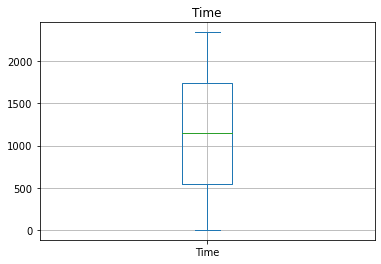

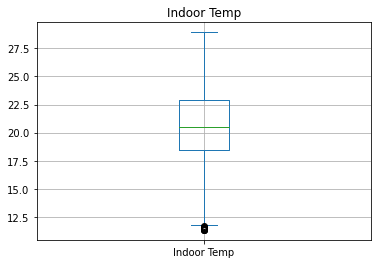

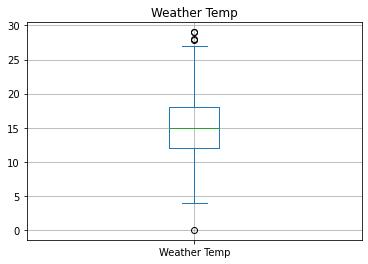

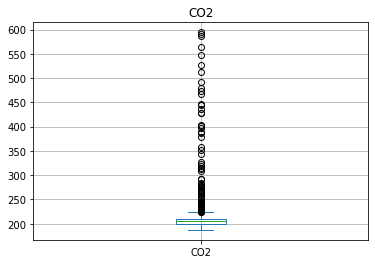

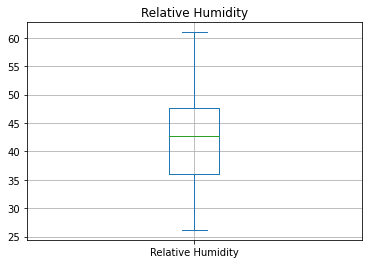

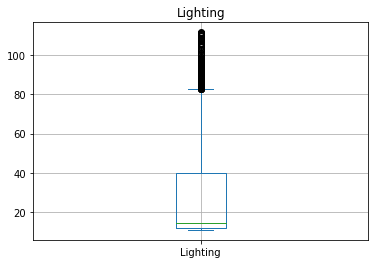

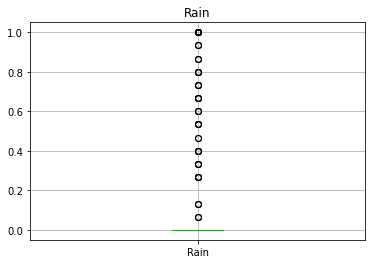

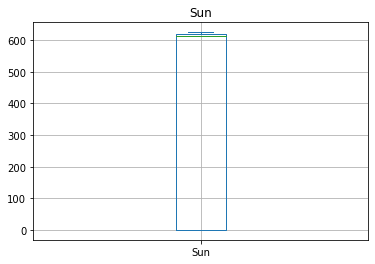

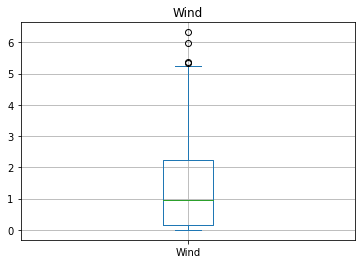

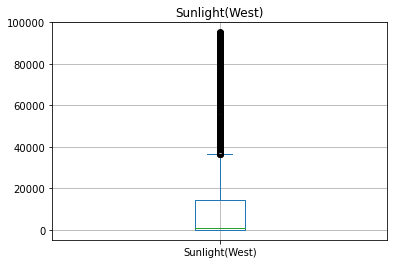

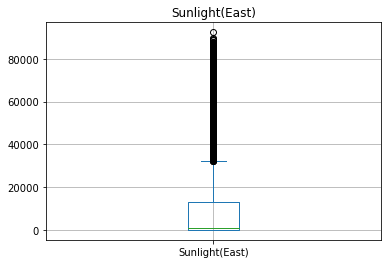

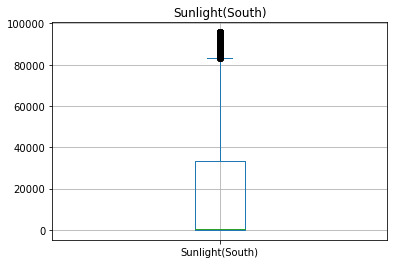

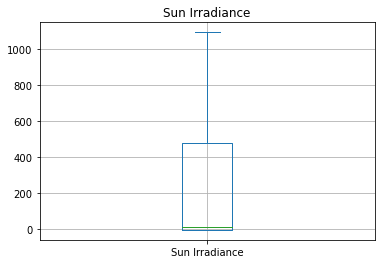

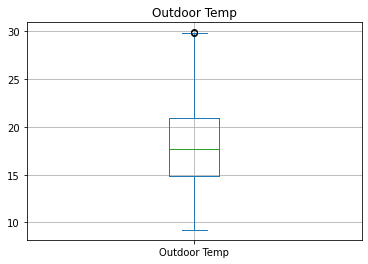

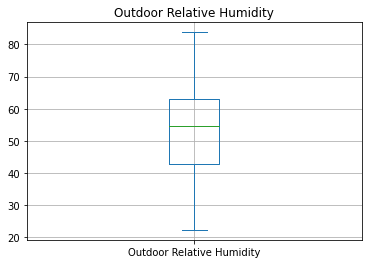

In [86]:
for col in df.columns:
    plot(col)

In [77]:
print(df.describe())

       Indoor Temp  Weather Temp          CO2  Relative Humidity     Lighting  \
count  4137.000000   4137.000000  4137.000000        4137.000000  4137.000000   
mean     20.493530     15.092676   206.599835          42.389879    28.970248   
std       3.312096      4.375374    22.763114           7.215405    25.684356   
min      11.352000      0.000000   187.339000          26.173300    10.740000   
25%      18.424600     12.000000   200.228000          36.088000    11.540700   
50%      20.499300     15.000000   205.131000          42.776000    14.126700   
75%      22.865300     18.000000   210.016000          47.584000    40.034700   
max      28.924000     29.000000   594.389000          60.957300   111.797000   

              Rain          Sun         Wind  Sunlight(West)  Sunlight(East)  \
count  4137.000000  4137.000000  4137.000000     4137.000000     4137.000000   
mean      0.038756   335.094312     1.304623    14749.149509    13566.284958   
std       0.187128   304.51303

In [81]:
print(df)

       Time  Indoor Temp  Weather Temp      CO2  Relative Humidity  Lighting  \
0     11:45      18.1875        0.0000  216.560            39.9125   81.6650   
1     12:00      18.4633        6.8000  219.947            39.9267   81.7413   
2     12:15      18.7673       17.0000  219.403            39.7720   81.4240   
3     12:30      19.0727       18.0000  218.613            39.7760   81.5013   
4     12:45      19.3721       20.0000  217.714            39.7757   81.4657   
...     ...          ...           ...      ...                ...       ...   
4132  06:30      18.8000       11.0000  199.424            43.0160   21.8500   
4133  06:45      18.7713       11.7333  199.200            43.1920   21.1653   
4134  07:00      18.7860       12.0000  199.435            43.3947   21.2640   
4135  07:15      18.8133       12.5333  200.107            43.3440   28.1647   
4136  07:30      18.8600       13.0000  200.149            43.6667   31.1107   

      Rain      Sun      Wind  Sunlight

In [88]:
df.to_csv('data/data_cleaned.csv', index=False)